# UD04 · Reto de dibujo (CE 4b, 4c)

**Duración estimada:** 2 h (S2 + TA2) · **Objetivo:** escribir un script que haga al DOBOT dibujar una figura con el portaminas y **validarlo sin hardware** con `BrazoSimulado`.

> Actividad 2 de la [UD04](../actividades/act2_reto_dibujo.md). Cada equipo tiene una figura distinta.

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt


class BrazoSimulado:
    """Imita la API de pydobot y valida el script SIN hardware."""

    X_MIN, X_MAX = 150.0, 320.0     # rango de X permitido
    RADIO_MAX = 320.0               # alcance del DOBOT Magician
    Z_MIN, Z_MAX = -80.0, 140.0     # limites de Z

    def __init__(self):
        self.pos = [200.0, 0.0, 50.0, 0.0]
        self.pinza_cerrada = False
        self.traza = []

    def _validar(self, x, y, z, r):
        if not (self.X_MIN <= x <= self.X_MAX):
            raise ValueError(f"X={x} fuera de [{self.X_MIN}, {self.X_MAX}]")
        if math.hypot(x, y) > self.RADIO_MAX:
            raise ValueError(f"radio {math.hypot(x, y):.1f} > {self.RADIO_MAX}")
        if not (self.Z_MIN <= z <= self.Z_MAX):
            raise ValueError(f"Z={z} fuera de [{self.Z_MIN}, {self.Z_MAX}]")

    def move_to(self, x, y, z, r=0.0, wait=True):
        self._validar(x, y, z, r)
        self.pos = [float(x), float(y), float(z), float(r)]
        self.traza.append(("move", float(x), float(y), float(z)))

    def gripper(self, cerrar=True):
        self.pinza_cerrada = bool(cerrar)
        self.traza.append(("gripper", cerrar))

    def suction(self, activar=True):
        self.traza.append(("suction", activar))

    def wait(self, ms):
        self.traza.append(("wait", ms))

    def home(self):
        self.move_to(200, 0, 50, 0)

    def resumen(self):
        return f"ordenes={len(self.traza)} pinza={'cerrada' if self.pinza_cerrada else 'abierta'} pos={self.pos}"

    def dibujar_trayectoria(self, titulo="Trayectoria XY (lapiz abajo)", z_pen=0.0):
        pts = [(t[1], t[2]) for t in self.traza if t[0] == "move" and t[3] <= z_pen]
        plt.figure(figsize=(5, 5))
        if pts:
            xs, ys = zip(*pts)
            plt.plot(xs, ys, "-o", markersize=3)
        plt.scatter([0], [0], c="k", marker="x", label="base")
        plt.gca().add_patch(plt.Circle((0, 0), self.RADIO_MAX, fill=False, ls="--", color="gray"))
        plt.axis("equal"); plt.grid(True); plt.title(titulo)
        plt.xlabel("X (mm)"); plt.ylabel("Y (mm)"); plt.legend()
        plt.show()

## 1. Cómo se dibuja

1. Posicionar el lápiz **arriba** (Z alta) en el primer vértice.
2. Recorrer los vértices con el lápiz **abajo** (Z de dibujo).
3. `dibujar_trayectoria()` comprueba el resultado **antes** de enviarlo al robot.

ordenes=6 pinza=abierta pos=[250.0, -25.0, 0.0, 0.0]


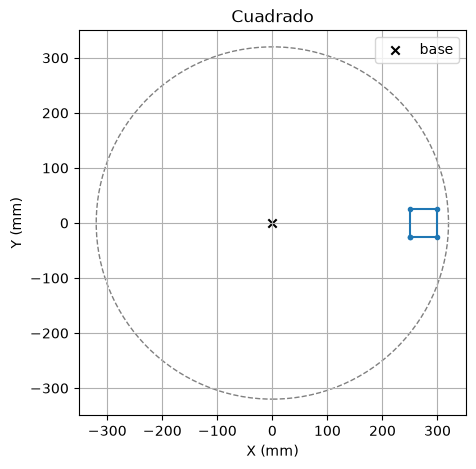

In [2]:
# Ejemplo: un cuadrado (¡cambiadlo por vuestra figura!)
brazo = BrazoSimulado()
vertices = [(250, -25), (250, 25), (300, 25), (300, -25), (250, -25)]

brazo.move_to(vertices[0][0], vertices[0][1], 20)   # posicionar con lapiz arriba
for (x, y) in vertices:                               # recorrer con lapiz abajo
    brazo.move_to(x, y, 0)

print(brazo.resumen())
brazo.dibujar_trayectoria("Cuadrado")

## 2. Vuestro reto

Completad una función **`dibujar(figura)`** que sirva para **cuadrado, triángulo, pentágono o las iniciales** del equipo. Definid los vértices de vuestra figura y comprobad la trayectoria.

In [3]:
def dibujar(figura):
    # TODO: define los vertices de tu figura y mueve el brazo
    # Pista: define ir_a(p), bajar(), subir(); y una lista de vertices.
    ...

# dibujar("triangulo")

## 3. Del simulador al robot real (referencia)

Este es el mismo movimiento con la **API real** (`pydobot`). El script que validáis aquí es el que se carga en el portátil del brazo.

```python
# from pydobot import Dobot
# robot = Dobot(port="COM5")           # o "/dev/ttyUSB0"
# robot.move_to(x, y, z, r)            # x, y, z, r  (mm y grados)
# robot.wait(200)
# robot.home(); robot.close()
```

> **CE 4c:** anota en una celda de texto por qué programáis en **offline** (validar sin el robot) y qué ventaja tiene frente al modo teach.